# χ行列の主要エラー要素とdrive校正

このノートは**設定と実行だけ**を担当します。関数、QPT、CPTP射影、fit、描画、キャッシュ処理はPython側へ移しました。

- 設定API: `chi_error_nbar_workflow.py`
- 解析実装: `chi_error_nbar_analysis_impl.py`
- 独立検証ステージ: `chi_error_nbar_stages.py`
- drive補正式: `drive_amplitude_calibration.py`
- drive再QPT解析: `drive_calibration_qpt_analysis.py`

通常は下の設定セルだけ変更し、最後の`workflow.run(CONFIG)`を実行してください。重いフラグは既定で`False`です。

In [ ]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import display

import chi_error_nbar_workflow as workflow
import chi_error_nbar_stages as stages
workflow = importlib.reload(workflow)
stages = importlib.reload(stages)

: 

## 1. 共通設定

通常変更するのはこのセルです。

In [19]:
CONFIG = workflow.default_config()

CONFIG["OUTPUT_DIR"] = "results/chi_error_element_fit"
CONFIG["NBAR_GRID"] = np.r_[0.01, np.arange(0.25, 20.0001, 0.25)]
CONFIG["FIT_DEGREE"] = 4
CONFIG["ERROR_CHANNEL_CONVENTION"] = "undo_before_actual"

# 並列数。高n_barではメモリ使用量も増えるため、まず4を推奨。
CONFIG["PARALLEL_WORKERS"] = 4
CONFIG["FAST_PROCESS_WORKERS"] = 4

display(pd.Series({
    key: value for key, value in CONFIG.items()
    if key not in {"SIMULATION_PARAMS", "NBAR_GRID"}
}, name="value").to_frame())

,value
OUTPUT_DIR,results/chi_error_element_fit
RECOMPUTE,False
PARALLEL_WORKERS,4
FAST_PROCESS_WORKERS,4
FIT_DEGREE,4
ERROR_CHANNEL_CONVENTION,undo_before_actual
RUN_EXACT_FULL_CHI_SWEEP,False
RUN_NUMERICAL_CONVERGENCE,False
RUN_NOISE_SOURCE_ABLATION,False
FORCE_RECOMPUTE_PUBLICATION_CACHE,False


## 2. Hamiltonian・ノイズ設定

物理条件を変更する場合はこのセルだけ編集します。

In [20]:
SIMULATION_PARAMS = CONFIG["SIMULATION_PARAMS"]
SIMULATION_PARAMS.update({
    "A": 0.125,
    "delta": 0.5,
    "rho0": 0.0,
    "time_points": 500,
    "t_gate_phys": 100e-6,
    "heating_rate_phys": 10.0,
    "dephasing_rate_phys": 18.0,
    "T2_star": 0.3,
    "rayleigh_rate_phys": 3.0,
    "raman_rate_phys": 1.0,
    "eta": 0.1,
    "laser_intensity_fluctuation": 0.0,
    "laser_detuning_fluctuation": 0.0,
    "laser_rotation_angle_fluctuation": 0.0,
    "laser_noise_samples": 1,
    "laser_noise_seed": 1234,
    "use_full_order": True,
    "show_progress": True,
    "parallel_workers": CONFIG["PARALLEL_WORKERS"],
})
display(pd.Series(SIMULATION_PARAMS, name="value").to_frame())

,value
A,0.125
delta,0.5
rho0,0.0
time_points,500
t_gate_phys,0.0001
heating_rate_phys,10.0
dephasing_rate_phys,18.0
T2_star,0.3
rayleigh_rate_phys,3.0
raman_rate_phys,1.0


## 3. 論文用検証フラグ

`False`では保存済みキャッシュを読みます。`True`は不足点を計算します。`FORCE_*`は既存キャッシュも再計算します。

In [21]:
CONFIG.update({
    "RECOMPUTE": False,
    "RUN_EXACT_FULL_CHI_SWEEP": False,
    "RUN_NUMERICAL_CONVERGENCE": False,
    "RUN_NOISE_SOURCE_ABLATION": False,
    "FORCE_RECOMPUTE_PUBLICATION_CACHE": False,
    "CONVERGENCE_NBARS": [0.01, 4.0, 20.0],
    "ABLATION_NBARS": [0.01, 1.0, 4.0, 10.0, 20.0],
    "BOOTSTRAP_SAMPLES": 1000,
    "BOOTSTRAP_SEED": 20260805,
    "CPTP_TOLERANCE": 1e-11,
    "CPTP_MAX_ITERATIONS": 5000,
    "FORCE_RECOMPUTE_ADVANCED_QPT": False,
    "RUN_PHYSICAL_CONTROL_QPT": False,
    "RUN_PARAMETER_ROBUSTNESS_QPT": False,
    "CONTROL_VALIDATION_NBARS": [0.01, 4.0, 20.0],
    "ROBUSTNESS_NBARS": [0.01, 4.0, 20.0],
})

## 4. $h_{XX}$ drive-amplitude校正

`RUN_HXX_DRIVE_CALIBRATION_QPT=True`にすると、補正振幅でfull-order master-equation QPTを実行します。各温度点は独立キャッシュなので中断・再開できます。

In [22]:
CONFIG.update({
    "RUN_HXX_DRIVE_CALIBRATION_QPT": False,
    "FORCE_RECOMPUTE_HXX_DRIVE_QPT": False,
    "HXX_DRIVE_CALIBRATION_NBARS": [
        0.01, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0,
    ],
    "HXX_MAX_FEEDBACK_ITERATIONS": 2,
    "HXX_CONVERGENCE_TOL_RAD": 2e-3,
    "HXX_MAX_AMPLITUDE_FACTOR": 1.6,
    "TARGET_XX_ANGLE_RAD": np.pi / 4.0,

    # 実機値がある場合: K = f_mode[Hz] * t_gate[s]
    "KIRCHHOFF_REFERENCE_K": None,
    "KIRCHHOFF_LOOP_NUMBER": 1.0,
    "KIRCHHOFF_SCAN_K_MAX": 250.0,
})

## 5. 基本解析と保存済み検証の読込

設定を検証した後、解析本体を一度だけ呼びます。重いフラグが`False`なら既存キャッシュを読みます。以下の独立検証セルより先に一度実行してください。

Sweep points: 81 (0.01 ... 20.0)
Cache: results/chi_error_element_fit/chi_error_element_sweep.csv
RECOMPUTE = False
data_source
direct_simulation    81


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
0,0.01,0.000353,-0.000524,0.013702,0.013712,direct_simulation
1,0.25,0.000537,-0.000652,0.017362,0.017375,direct_simulation
2,0.50,0.000784,-0.000783,0.021154,0.021168,direct_simulation
3,0.75,0.001086,-0.000912,0.024922,0.024938,direct_simulation
4,1.00,0.001443,-0.001040,0.028665,0.028684,direct_simulation


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
76,19.00,0.101549,-0.006603,0.218649,0.218748,direct_simulation
77,19.25,0.103312,-0.006645,0.220304,0.220404,direct_simulation
78,19.50,0.105075,-0.006686,0.221939,0.222039,direct_simulation
79,19.75,0.106836,-0.006727,0.223554,0.223655,direct_simulation
80,20.00,0.108596,-0.006767,0.225149,0.225251,direct_simulation


,element,degree,R_squared,RMSE,max_abs_residual
0,"\chi_{XX,XX}",1,0.946932,0.007761,0.012785
1,"\chi_{XX,XX}",2,0.997520,0.001678,0.003694
2,"\chi_{XX,XX}",3,0.999973,0.000174,0.000442
3,"\chi_{XX,XX}",4,1.000000,0.000007,0.000022
4,"\chi_{XX,XX}",5,1.000000,0.000003,0.000009
5,"|\chi_{II,XX}|",1,0.968919,0.010920,0.022739
6,"|\chi_{II,XX}|",2,0.999973,0.000322,0.000999
7,"|\chi_{II,XX}|",3,0.999995,0.000139,0.000280
8,"|\chi_{II,XX}|",4,1.000000,0.000033,0.000080
9,"|\chi_{II,XX}|",5,1.000000,0.000004,0.000011


,element,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"\chi_{XX,XX}",4,0.01,0.000353,1.0,0.000007,0.000022,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,0.000658,0.000465,-0.000015,1.788963e-07
1,"|\chi_{II,XX}|",4,0.01,0.013712,1.0,0.000033,0.000080,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,0.015401,-0.000220,-0.000004,1.387494e-07


**\chi_{XX,XX}**: `y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)^1 + 4.64640231e-04(n-0.01)^2 - 1.49132984e-05(n-0.01)^3 + 1.78896312e-07(n-0.01)^4`<br>$R^2=0.99999996$, RMSE = 6.598e-06

**|\chi_{II,XX}|**: `y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)^1 - 2.20121505e-04(n-0.01)^2 - 3.81084908e-06(n-0.01)^3 + 1.38749425e-07(n-0.01)^4`<br>$R^2=0.99999972$, RMSE = 3.305e-05

Saved: results/chi_error_element_fit/chi_error_element_fit_summary.csv


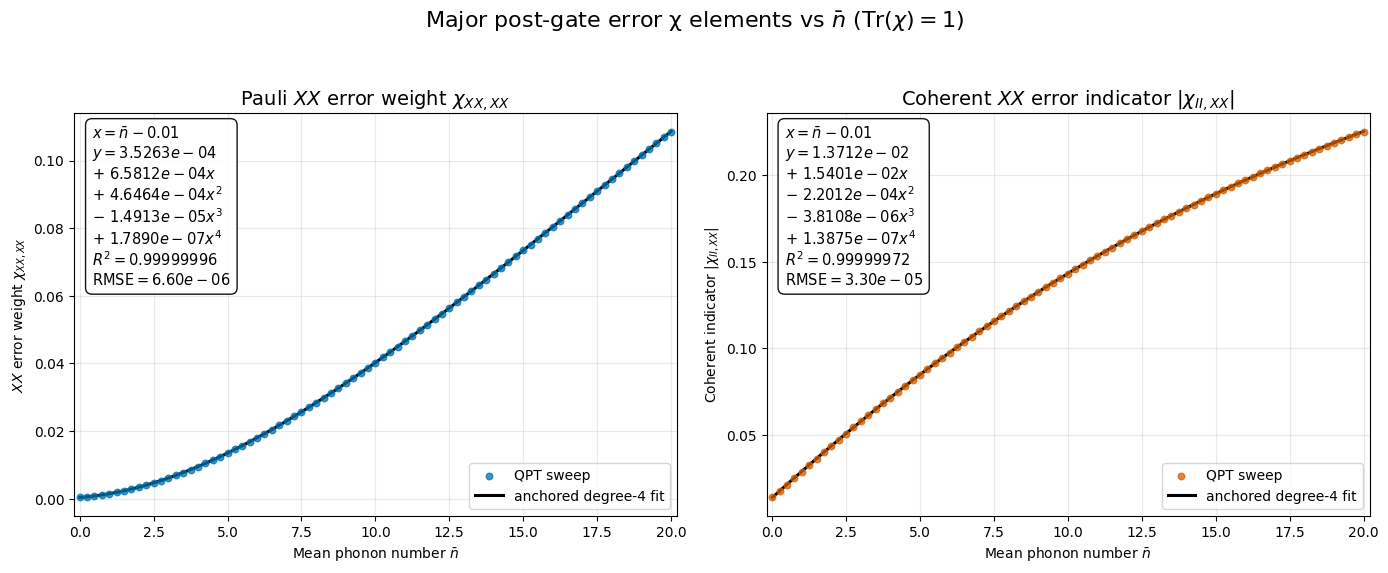

Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_error_element_fit_curves.csv


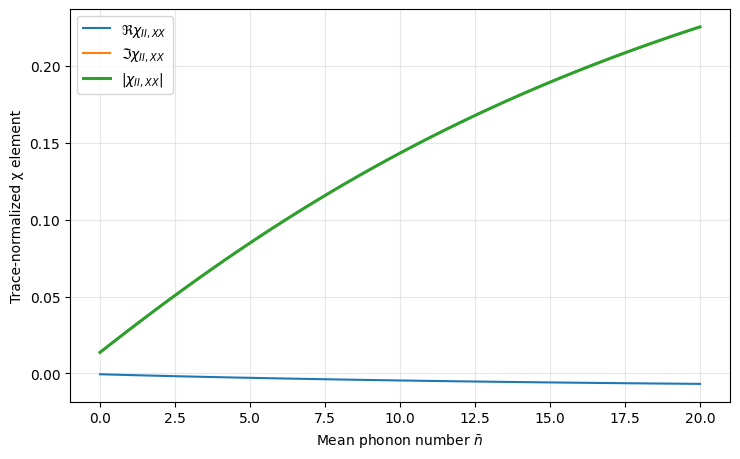

Saved: results/chi_error_element_fit/chi_II_XX_complex_components.png
Selected other major Pauli noises: ['IX', 'XI']
Selection threshold: 1.0% of max chi[XX,XX]


,pauli,max_over_sweep,value_at_nbar_0p01,value_at_nbar_20,relative_to_XX_peak
2,IX,6.792169e-03,5.489609e-04,6.792169e-03,0.062546
3,XI,6.792169e-03,5.489658e-04,6.792169e-03,0.062546
4,IZ,1.742226e-04,1.742226e-04,1.307732e-04,0.001604
5,ZI,1.742221e-04,1.742221e-04,1.307772e-04,0.001604
6,YX,1.742133e-04,1.742133e-04,1.306923e-04,0.001604
7,XY,1.742125e-04,1.742125e-04,1.306950e-04,0.001604
8,IY,1.149983e-04,7.137986e-05,1.149909e-04,0.001059
9,YI,1.149873e-04,7.138454e-05,1.149873e-04,0.001059
10,ZX,1.147266e-04,7.136353e-05,1.147266e-04,0.001056
11,XZ,1.147244e-04,7.136854e-05,1.147244e-04,0.001056


Saved: results/chi_error_element_fit/chi_pauli_diagonal_noise_ranking.csv


,element,pauli,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"chi_{IX,IX}",IX,4,0.01,0.000549,1.0,8.403856e-07,0.000004,y(n) = 5.48960862e-04 + 5.35969980e-04(n-0.01)...,0.000536,-0.000016,3.219822e-07,-3.759491e-09
1,"chi_{XI,XI}",XI,4,0.01,0.000549,1.0,8.423585e-07,0.000004,y(n) = 5.48965783e-04 + 5.35964832e-04(n-0.01)...,0.000536,-0.000016,3.219415e-07,-3.758916e-09


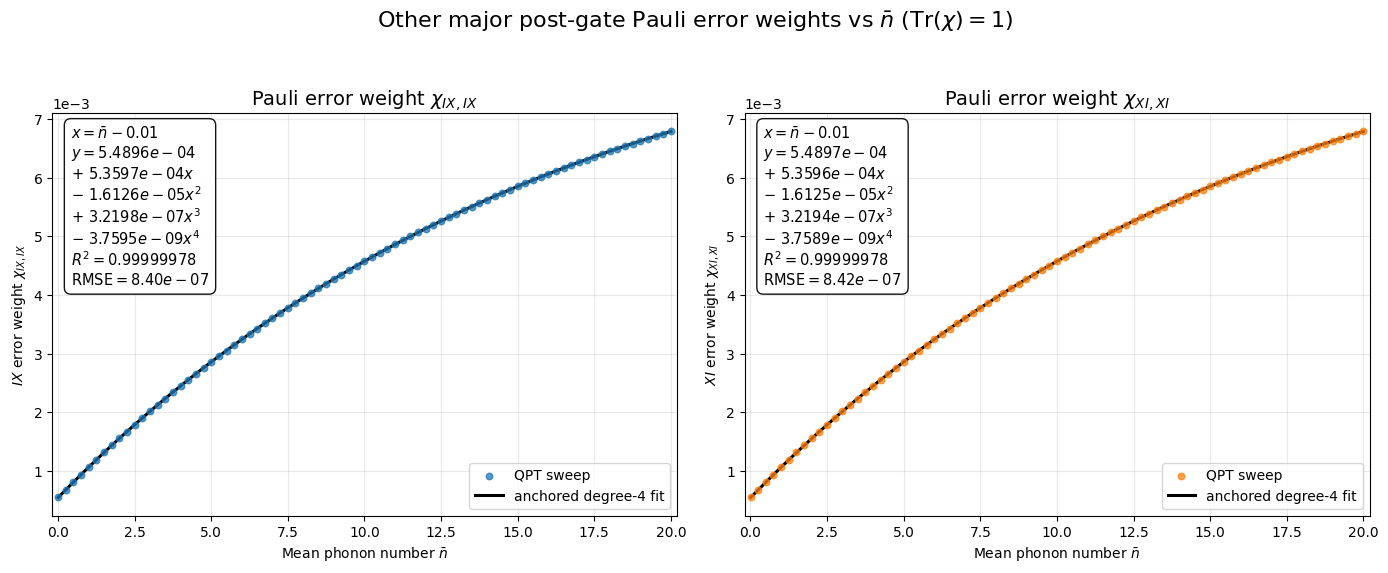

Saved: results/chi_error_element_fit/chi_other_major_noise_fit_summary.csv
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_other_major_noise_fit_curves.csv
Heavy publication checks:
 exact full chi sweep = False
 numerical convergence = False
 noise-source ablation = False
Exact full-chi cache: 81/81 points


,n_bar,phonon_dim,raw_trace_real,raw_trace_imag,trace_normalized_hermiticity_fro,convention_error_fro,dimension,choi_trace,expected_choi_trace_for_tp,choi_trace_error,tp_frobenius_error,tp_max_abs_error,min_choi_eigenvalue,negative_choi_eigenvalue_count,tp_pass,cp_pass
0,0.01,20,16.0,1.799442e-17,8.226611e-16,0.0,4,4.0,4,4.441120e-16,1.681932e-15,7.229287e-16,1.471214e-07,0,True,True
1,0.25,21,16.0,1.985790e-18,6.069958e-16,0.0,4,4.0,4,4.964476e-19,2.740699e-15,1.332274e-15,1.494379e-07,0,True,True
2,0.50,22,16.0,-2.433716e-17,5.477606e-16,0.0,4,4.0,4,6.084290e-18,1.991040e-15,9.281566e-16,1.420811e-07,0,True,True
3,0.75,23,16.0,6.855207e-18,4.378303e-16,0.0,4,4.0,4,1.713802e-18,2.008340e-15,7.771618e-16,1.823241e-07,0,True,True
4,1.00,25,16.0,2.000288e-17,5.075605e-16,0.0,4,4.0,4,4.441174e-16,2.288675e-15,8.881810e-16,1.429901e-07,0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,19.00,335,16.0,-3.857103e-18,2.477808e-16,0.0,4,4.0,4,2.664535e-15,9.018078e-15,4.440892e-15,-6.700579e-07,1,True,False
77,19.25,340,16.0,3.542461e-18,2.772767e-16,0.0,4,4.0,4,3.552714e-15,1.267060e-14,6.217249e-15,-6.877848e-07,1,True,False
78,19.50,345,16.0,-6.149587e-18,2.767528e-16,0.0,4,4.0,4,1.537406e-18,4.698263e-15,2.069290e-15,1.507784e-07,0,True,True
79,19.75,350,16.0,2.211852e-18,2.568161e-16,0.0,4,4.0,4,2.664535e-15,1.012739e-14,4.006352e-15,-1.492663e-06,1,True,False


,n_bar,case,phonon_dim,time_points,solver_atol,solver_rtol,chi_frobenius_difference_from_baseline,delta_chi_XX_XX,delta_abs_chi_II_XX,delta_chi_IX_IX,delta_chi_XI_XI
0,0.01,baseline,20,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.01,phonon_cutoff_1p2x,24,500,1.000000e-12,1.000000e-09,1.410168e-07,9.710042e-09,1.165605e-08,7.880690e-09,-8.881181e-09
2,0.01,time_grid_750,20,750,1.000000e-12,1.000000e-09,1.582912e-05,-3.052450e-07,-1.117783e-05,1.166916e-08,5.758157e-09
3,0.01,strict_solver_tol,20,500,1.000000e-13,1.000000e-10,8.278577e-08,1.174198e-10,-1.357508e-08,3.024249e-09,-1.277186e-09
4,4.00,baseline,67,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,4.00,phonon_cutoff_1p2x,81,500,1.000000e-12,1.000000e-09,1.402904e-06,3.215637e-08,7.809372e-07,-2.203228e-07,-1.887032e-07
6,4.00,time_grid_750,67,750,1.000000e-12,1.000000e-09,1.466400e-05,-1.312070e-06,-1.027634e-05,-1.418031e-08,-2.657212e-08
7,4.00,strict_solver_tol,67,500,1.000000e-13,1.000000e-10,1.712174e-07,5.031036e-09,-6.898890e-08,1.693588e-08,4.986855e-09
8,20.00,baseline,354,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,20.00,phonon_cutoff_1p2x,425,500,1.000000e-12,1.000000e-09,5.976264e-07,-2.074160e-08,7.789447e-08,7.641196e-09,4.023760e-08


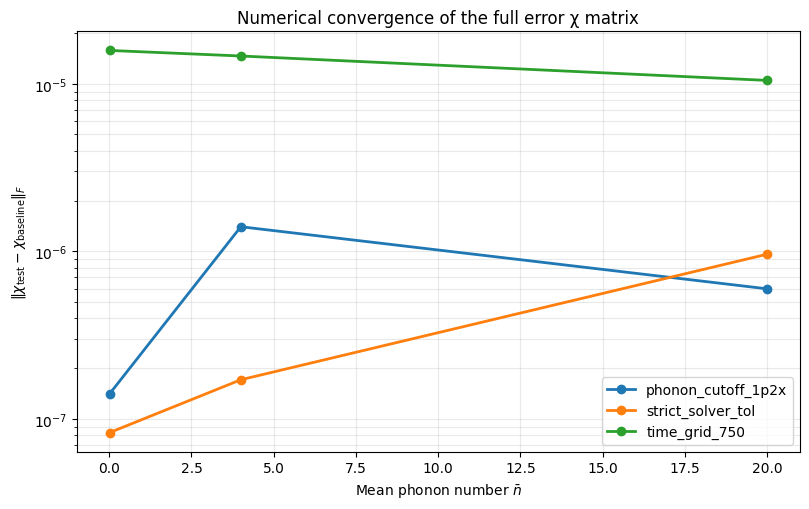

Saved: results/chi_error_element_fit/numerical_convergence/numerical_convergence_summary.csv


,n_bar,noise_source,observable,leave_one_out_all_minus_without,isolated_only_minus_none
0,0.01,motional_heating,chi_XX_XX,7.957329e-07,5.386332e-07
1,0.01,motional_heating,abs_chi_II_XX,8.271729e-06,4.243323e-06
2,0.01,motional_heating,chi_IX_IX,2.428858e-04,2.434732e-04
3,0.01,motional_heating,chi_XI_XI,2.428943e-04,2.434591e-04
4,0.01,motional_dephasing,chi_XX_XX,1.611454e-04,1.610577e-04
...,...,...,...,...,...
75,20.00,spin_dephasing,chi_XI_XI,-2.253780e-06,-3.397647e-07
76,20.00,photon_scattering,chi_XX_XX,-7.566620e-05,-7.754002e-05
77,20.00,photon_scattering,abs_chi_II_XX,-1.576945e-04,-1.603354e-04
78,20.00,photon_scattering,chi_IX_IX,1.992962e-05,2.428152e-05


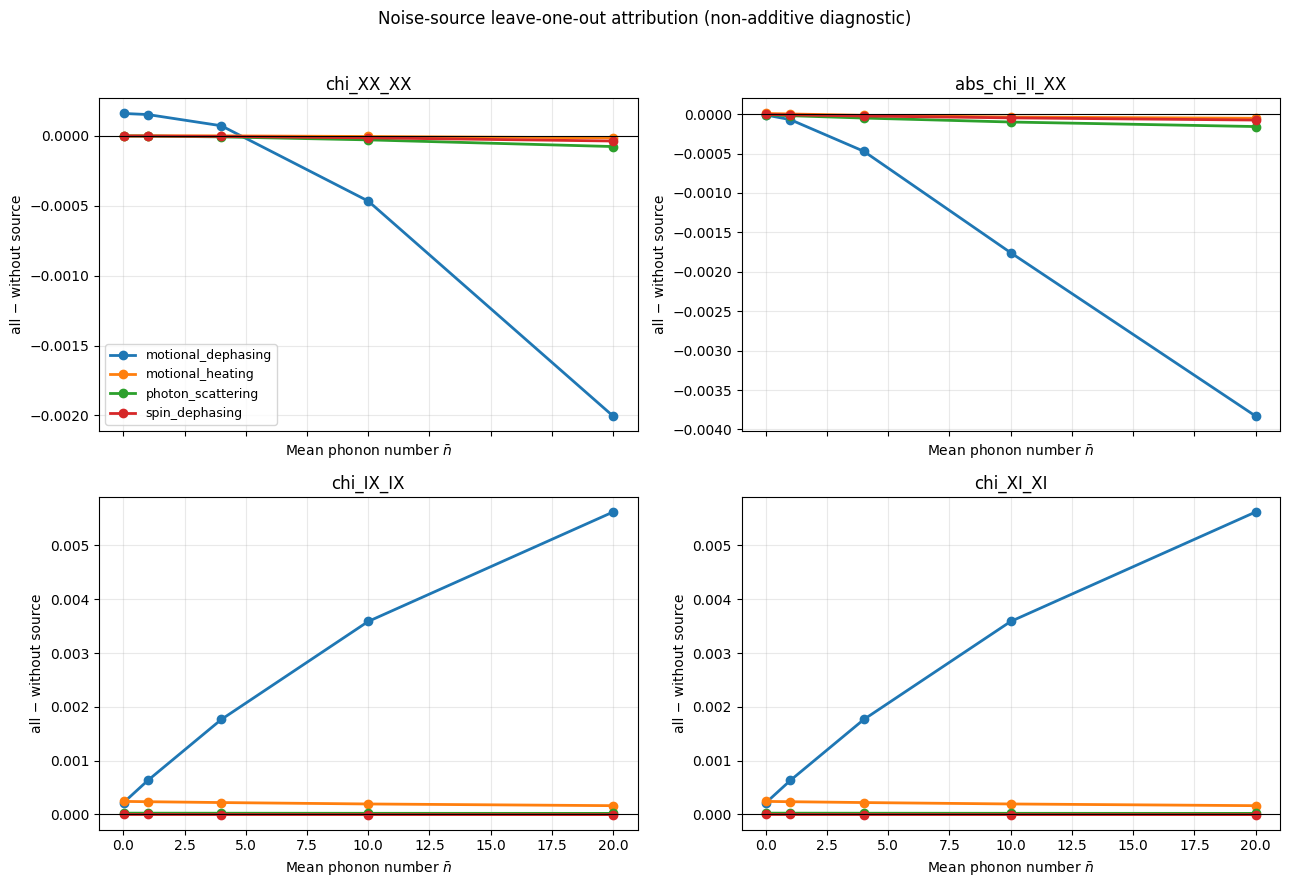

Saved: results/chi_error_element_fit/noise_source_ablation/noise_ablation_attribution.csv


,rank,component,row_pauli,column_pauli,is_diagonal,max_abs_over_sweep,mean_abs_over_sweep
0,1,"II,II",II,II,True,9.975668e-01,9.456226e-01
1,2,"II,XX",II,XX,False,2.252506e-01,1.348869e-01
2,3,"XX,XX",XX,XX,True,1.085955e-01,4.485163e-02
3,4,"IX,IX",IX,IX,True,6.792170e-03,4.271583e-03
4,5,"XI,XI",XI,XI,True,6.792169e-03,4.271585e-03
5,6,"IX,XI",IX,XI,False,6.767138e-03,4.246555e-03
6,7,"IZ,IZ",IZ,IZ,True,1.742226e-04,1.359991e-04
7,8,"ZI,ZI",ZI,ZI,True,1.742221e-04,1.360003e-04
8,9,"YX,YX",YX,YX,True,1.742133e-04,1.359290e-04
9,10,"XY,XY",XY,XY,True,1.742125e-04,1.359305e-04


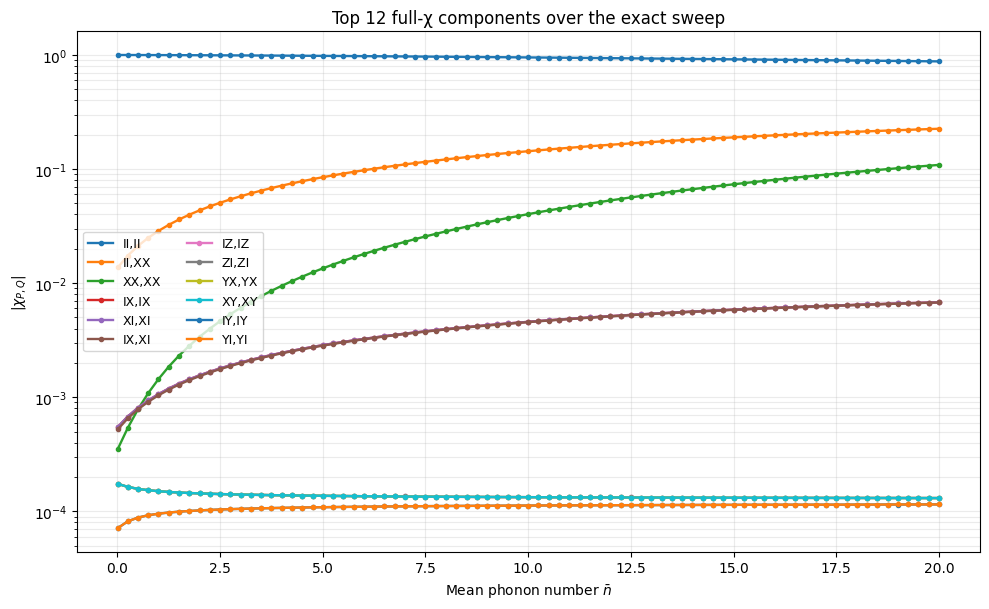

Saved: results/chi_error_element_fit/exact_full_chi/full_chi_component_ranking.csv


,target,degree,R_squared,RMSE,max_abs_residual,AICc,BIC,CV_RMSE_5fold,equation,best_AICc,best_CV
0,chi_XX_XX,1,0.946932,7.760765e-03,0.012785,-785.054610,-782.710794,0.010479,y(n) = 3.52629218e-04 + 4.77527537e-03(n-0.01)^1,False,False
1,chi_XX_XX,2,0.997520,1.677558e-03,0.003694,-1031.093536,-1026.458484,0.003749,y(n) = 3.52629218e-04 + 2.23953120e-03(n-0.01)...,False,False
2,chi_XX_XX,3,0.999973,1.736828e-04,0.000442,-1396.329630,-1389.457971,0.000668,y(n) = 3.52629218e-04 + 9.17962849e-04(n-0.01)...,False,False
3,chi_XX_XX,4,1.000000,6.597804e-06,0.000022,-1923.935023,-1914.883542,0.000036,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,False,True
4,chi_XX_XX,5,1.000000,3.109257e-06,0.000009,-2043.542556,-2032.370311,0.000048,y(n) = 3.52629218e-04 + 6.43673131e-04(n-0.01)...,True,False
5,abs_chi_II_XX,1,0.968919,1.091994e-02,0.022739,-729.730078,-727.386262,0.015573,y(n) = 1.37116490e-02 + 1.17197654e-02(n-0.01)^1,False,False
6,abs_chi_II_XX,2,0.999973,3.217210e-04,0.000999,-1298.621954,-1293.986902,0.000738,y(n) = 1.37116490e-02 + 1.53725441e-02(n-0.01)...,False,False
7,abs_chi_II_XX,3,0.999995,1.386060e-04,0.000280,-1432.876079,-1426.004420,0.000525,y(n) = 1.37116490e-02 + 1.56025015e-02(n-0.01)...,False,False
8,abs_chi_II_XX,4,1.000000,3.304733e-05,0.000080,-1662.919978,-1653.868497,0.000242,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,False,False
9,abs_chi_II_XX,5,1.000000,4.116071e-06,0.000011,-1998.099043,-1986.926797,0.000058,y(n) = 1.37116490e-02 + 1.53195461e-02(n-0.01)...,True,True


,target,chosen_degree,equation,R_squared,RMSE,AICc,BIC,CV_RMSE_5fold,bootstrap_samples,bootstrap_seed
0,chi_XX_XX,4,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,1.0,6.597804e-06,-1923.935023,-1914.883542,0.000036,1000,20260805
1,abs_chi_II_XX,4,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,1.0,3.304733e-05,-1662.919978,-1653.868497,0.000242,1000,20260805
2,chi_IX_IX,4,y(n) = 5.48960862e-04 + 5.35969980e-04(n-0.01)...,1.0,8.403856e-07,-2257.757298,-2248.705818,0.000005,1000,20260805
3,chi_XI_XI,4,y(n) = 5.48965783e-04 + 5.35964832e-04(n-0.01)...,1.0,8.423585e-07,-2257.377431,-2248.325951,0.000005,1000,20260805


,target,coefficient,estimate,ci95_lower,ci95_upper
0,chi_XX_XX,a0_anchor,3.526292e-04,3.526292e-04,3.526292e-04
1,chi_XX_XX,a1,6.581242e-04,6.554713e-04,6.607083e-04
2,chi_XX_XX,a2,4.646402e-04,4.639461e-04,4.653548e-04
3,chi_XX_XX,a3,-1.491330e-05,-1.497149e-05,-1.485770e-05
4,chi_XX_XX,a4,1.788963e-07,1.774487e-07,1.803992e-07
5,abs_chi_II_XX,a0_anchor,1.371165e-02,1.371165e-02,1.371165e-02
6,abs_chi_II_XX,a1,1.540097e-02,1.538819e-02,1.541325e-02
7,abs_chi_II_XX,a2,-2.201215e-04,-2.233023e-04,-2.166838e-04
8,abs_chi_II_XX,a3,-3.810849e-06,-4.101414e-06,-3.541870e-06
9,abs_chi_II_XX,a4,1.387494e-07,1.317239e-07,1.464881e-07


In [ ]:
workflow.validate_config(CONFIG)
RESULTS = workflow.run(CONFIG)
print("analysis completed")

## 6. 独立実行：drive補正後のfull-Hamiltonian再QPT

未完了の9温度点だけを対象にします。`RUN_DRIVE_RE_QPT=True`で計算し、完了済み点はキャッシュから自動的に飛ばします。

In [ ]:
DRIVE_RE_QPT_NBARS = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0]
RUN_DRIVE_RE_QPT = False
FORCE_DRIVE_RE_QPT = False

DRIVE_RE_QPT_RESULT = stages.run_drive_feedback_stage(
    CONFIG,
    DRIVE_RE_QPT_NBARS,
    run_qpt=RUN_DRIVE_RE_QPT,
    force_recompute=FORCE_DRIVE_RE_QPT,
    max_feedback_iterations=CONFIG["HXX_MAX_FEEDBACK_ITERATIONS"],
)
print(DRIVE_RE_QPT_RESULT["status"])
if not DRIVE_RE_QPT_RESULT["summary"].empty:
    display(DRIVE_RE_QPT_RESULT["summary"])

: 

## 7. 独立実行：Kirchhoff解析式との直接比較

`K=f_mode[Hz] * t_gate[s]`です。実機のmode周波数を設定するか、既知の`K`を直接設定してください。両方が`None`の場合は計算せず待機します。

In [ ]:
KIRCHHOFF_MODE_FREQUENCY_HZ = None
KIRCHHOFF_REFERENCE_K = None
KIRCHHOFF_LOOP_NUMBER = 1.0

KIRCHHOFF_DIRECT_RESULT = None
if KIRCHHOFF_MODE_FREQUENCY_HZ is None and KIRCHHOFF_REFERENCE_K is None:
    print("Set KIRCHHOFF_MODE_FREQUENCY_HZ or KIRCHHOFF_REFERENCE_K.")
else:
    KIRCHHOFF_DIRECT_RESULT = stages.run_kirchhoff_direct_comparison_stage(
        CONFIG,
        mode_frequency_hz=KIRCHHOFF_MODE_FREQUENCY_HZ,
        reference_k=KIRCHHOFF_REFERENCE_K,
        loop_number=KIRCHHOFF_LOOP_NUMBER,
    )
    print(KIRCHHOFF_DIRECT_RESULT["reference"])
    display(KIRCHHOFF_DIRECT_RESULT["comparison"])

: 

## 8. 独立実行：他の物理制御との比較

固定drive scan、gate time、detuning、$\sin^2$ pulse、Blackman pulseを同じfull-Hamiltonian QPTとCPTP指標で比較します。既定条件は11候補×3温度=33点です。

In [ ]:
CONTROL_QPT_NBARS = [0.01, 4.0, 20.0]
RUN_CONTROL_QPT = False
FORCE_CONTROL_QPT = False

DRIVE_AMPLITUDE_FACTORS = [0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
GATE_TIME_FACTORS = [0.97, 1.03]
DETUNING_FACTORS = [0.97, 1.03]
PULSE_SHAPES = ["sin2", "blackman"]

PHYSICAL_CONTROL_RESULT = stages.run_physical_control_stage(
    CONFIG,
    CONTROL_QPT_NBARS,
    run_qpt=RUN_CONTROL_QPT,
    force_recompute=FORCE_CONTROL_QPT,
    amplitude_factors=DRIVE_AMPLITUDE_FACTORS,
    gate_time_factors=GATE_TIME_FACTORS,
    detuning_factors=DETUNING_FACTORS,
    pulse_shapes=PULSE_SHAPES,
)
print(PHYSICAL_CONTROL_RESULT["status"])
display(PHYSICAL_CONTROL_RESULT["candidates"])
display(PHYSICAL_CONTROL_RESULT["best"])

## 9. 独立実行：パラメータ頑健性

$\eta$、$A/\delta$、gate time、motional dephasing rateを個別に変更し、$h_{XX}$、$\gamma_{XX}$、average infidelityを再評価します。既定条件は9条件×3温度=27点です。

In [ ]:
ROBUSTNESS_QPT_NBARS = [0.01, 4.0, 20.0]
RUN_ROBUSTNESS_QPT = False
FORCE_ROBUSTNESS_QPT = False

ETA_FACTORS = [0.8, 1.2]
A_OVER_DELTA_FACTORS = [0.9, 1.1]
ROBUSTNESS_GATE_TIME_FACTORS = [0.95, 1.05]
MOTIONAL_DEPHASING_FACTORS = [0.0, 0.5, 2.0]

ROBUSTNESS_RESULT = stages.run_parameter_robustness_stage(
    CONFIG,
    ROBUSTNESS_QPT_NBARS,
    run_qpt=RUN_ROBUSTNESS_QPT,
    force_recompute=FORCE_ROBUSTNESS_QPT,
    eta_factors=ETA_FACTORS,
    a_over_delta_factors=A_OVER_DELTA_FACTORS,
    gate_time_factors=ROBUSTNESS_GATE_TIME_FACTORS,
    motional_dephasing_factors=MOTIONAL_DEPHASING_FACTORS,
)
print(ROBUSTNESS_RESULT["status"])
display(ROBUSTNESS_RESULT["conditions"])
display(ROBUSTNESS_RESULT["summary"])

## 10. 主要結果

詳細なCSV・PNG・PDFは`CONFIG["OUTPUT_DIR"]`以下へ保存されます。

In [ ]:
RESULT_TABLES = [
    "fit_summary_df",
    "advanced_publication_summary_df",
    "final_drive_calibration_df",
]
for table_name in RESULT_TABLES:
    table = RESULTS.get(table_name)
    if isinstance(table, pd.DataFrame) and not table.empty:
        print(table_name)
        display(table)